# Project 4 :- AI - Based Recommendation System

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity  # users/movies ke beech similarity find karne ke liye
from sklearn.model_selection import train_test_split

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
df = pd.merge(ratings, movies, on="movieId")
# Dono files ko jod diya based on movieId
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# EDA

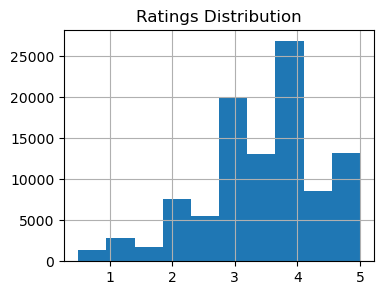

In [6]:
plt.figure(figsize=(4,3))
df['rating'].hist(bins=10)
plt.title("Ratings Distribution")
plt.show()

In [7]:
top_movies = df.groupby('title')['rating'].count()\
               .sort_values(ascending=False)\
               .head(10)

print(top_movies)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


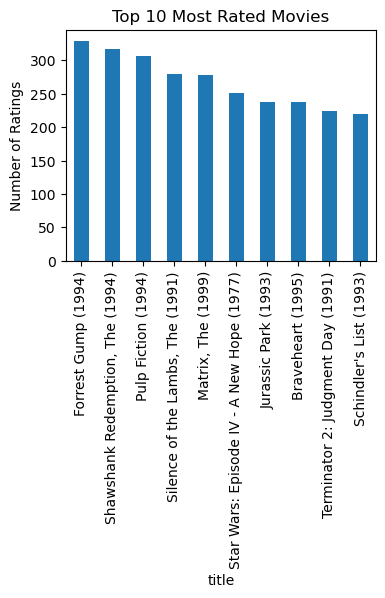

In [8]:
plt.figure(figsize=(4,3))
top_movies.plot(kind='bar')
plt.title("Top 10 Most Rated Movies")
plt.ylabel("Number of Ratings")
plt.show()

In [9]:
top_users = df.groupby('userId')['rating'].count()\
              .sort_values(ascending=False)\
              .head(10)

print(top_users)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: rating, dtype: int64


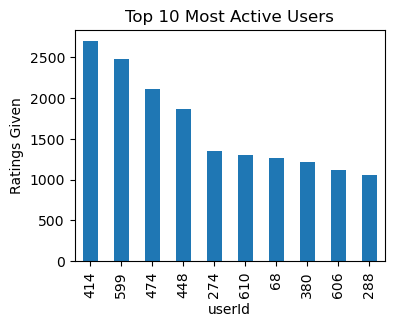

In [10]:
plt.figure(figsize=(4,3))
top_users.plot(kind='bar')
plt.title("Top 10 Most Active Users")
plt.ylabel("Ratings Given")
plt.show()

In [11]:
avg_rating = df.groupby('title')['rating'].mean()\
               .sort_values(ascending=False)\
               .head(10)

print(avg_rating)

title
Gena the Crocodile (1969)                    5.0
True Stories (1986)                          5.0
Cosmic Scrat-tastrophe (2015)                5.0
Love and Pigeons (1985)                      5.0
Red Sorghum (Hong gao liang) (1987)          5.0
Thin Line Between Love and Hate, A (1996)    5.0
Lesson Faust (1994)                          5.0
Eva (2011)                                   5.0
Who Killed Chea Vichea? (2010)               5.0
Siam Sunset (1999)                           5.0
Name: rating, dtype: float64


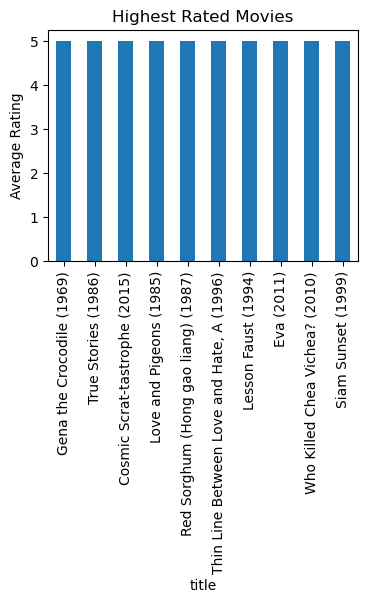

In [12]:
plt.figure(figsize = (4,3))
avg_rating.plot(kind='bar')
plt.title("Highest Rated Movies")
plt.ylabel("Average Rating")
plt.show()

# User-Movie Matrix

In [13]:
# Ye step data ko matrix form me convert karta hai
user_movie_matrix = df.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

user_movie_matrix.fillna(0, inplace=True)   # fillna(0):- jahan user ne movie nahi dekhi → 0 fill kar diya

# Pattern Learning and convert to dataframe

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_movie_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

# Recommendation Function

In [15]:
def recommend(user_id, n=5):
    # Step 1: similar users find karo
    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6]
    # Step 2: un users ki movies lo
    users = similar_users.index

    temp = df[df["userId"].isin(users)]
    # Step 3: average rating nikaalo
    recommendations = temp.groupby("title")["rating"].mean()
    # Step 4: top movies return
    return recommendations.sort_values(ascending=False).head(n)

In [16]:
print(recommend(1))  # userId = 1 (jis user ke liye movies recommend karni hai)

title
Ref, The (1994)                                                  5.0
Pirates of the Caribbean: The Curse of the Black Pearl (2003)    5.0
Dirty Work (1998)                                                5.0
Wallace & Gromit: The Best of Aardman Animation (1996)           5.0
Doctor Zhivago (1965)                                            5.0
Name: rating, dtype: float64
